Detected Type: bright
Brightness: 196.3225302455437
Contrast: 49.962136203216154


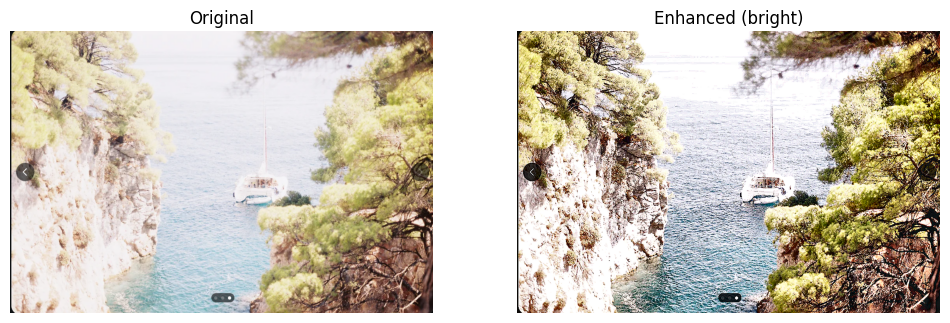

Saved as enhanced_output.jpg


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


class IntelligentEnhancer:
    def __init__(self):
        pass

    # -------------------------------
    # 1. Analyze image characteristics
    # -------------------------------
    def analyze_image(self, image):
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        brightness = np.mean(gray)
        contrast = np.std(gray)

        # Histogram for deeper analysis
        hist = cv2.calcHist([gray], [0], None, [256], [0, 256])
        hist = hist / hist.sum()

        return {
            "brightness": brightness,
            "contrast": contrast,
            "histogram": hist
        }

    # -------------------------------
    # 2. Classify image condition
    # -------------------------------
    def classify_image(self, stats):
        brightness = stats["brightness"]
        contrast = stats["contrast"]

        if brightness < 80:
            return "dark"
        elif brightness > 180:
            return "bright"
        elif contrast < 50:
            return "low_contrast"
        else:
            return "normal"

    # -------------------------------
    # 3A. Gamma correction helper
    # -------------------------------
    def gamma_correction(self, image, gamma):
        invGamma = 1.0 / gamma
        table = np.array([
            ((i / 255.0) ** invGamma) * 255 for i in range(256)
        ]).astype("uint8")

        return cv2.LUT(image, table)

    # -------------------------------
    # 3B. CLAHE helper
    # -------------------------------
    def apply_clahe(self, image, clip=2.0):
        lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)

        clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=(8, 8))
        l = clahe.apply(l)

        merged = cv2.merge((l, a, b))
        return cv2.cvtColor(merged, cv2.COLOR_LAB2BGR)

    # -------------------------------
    # 3C. Sharpen helper
    # -------------------------------
    def sharpen(self, image):
        kernel = np.array([[0, -1, 0],
                           [-1, 5, -1],
                           [0, -1, 0]])
        return cv2.filter2D(image, -1, kernel)

    # -------------------------------
    # 3D. Denoise helper
    # -------------------------------
    def denoise(self, image):
        return cv2.fastNlMeansDenoisingColored(image, None, 10, 10, 7, 21)

    # -------------------------------
    # 4A. Enhance dark image
    # -------------------------------
    def enhance_dark(self, image):
        image = self.gamma_correction(image, gamma=1.5)
        image = self.apply_clahe(image, clip=2.0)
        image = self.denoise(image)
        image = self.sharpen(image)
        return image

    # -------------------------------
    # 4B. Enhance bright image
    # -------------------------------
    def enhance_bright(self, image):
        image = self.gamma_correction(image, gamma=0.7)
        image = cv2.convertScaleAbs(image, alpha=1.2, beta=-20)
        image = self.apply_clahe(image, clip=1.5)
        image = self.sharpen(image)
        return image

    # -------------------------------
    # 4C. Enhance low contrast image
    # -------------------------------
    def enhance_low_contrast(self, image):
        image = self.apply_clahe(image, clip=3.0)
        image = self.gamma_correction(image, gamma=1.2)
        image = self.sharpen(image)
        return image

    # -------------------------------
    # 5. Main pipeline
    # -------------------------------
    def enhance(self, image):
        stats = self.analyze_image(image)
        category = self.classify_image(stats)

        if category == "dark":
            enhanced = self.enhance_dark(image)

        elif category == "bright":
            enhanced = self.enhance_bright(image)

        elif category == "low_contrast":
            enhanced = self.enhance_low_contrast(image)

        else:
            enhanced = image.copy()

        return enhanced, category, stats


# -------------------------------
# Utility functions
# -------------------------------
def show_results(original, enhanced, category):
    original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    enhanced_rgb = cv2.cvtColor(enhanced, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(original_rgb)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(enhanced_rgb)
    plt.title(f"Enhanced ({category})")
    plt.axis("off")

    plt.show()


# -------------------------------
# MAIN EXECUTION
# -------------------------------
if __name__ == "__main__":

    image_path = "/content/brightoverexposed taskk3.png"   # <-- put your image here
    image = cv2.imread(image_path)

    if image is None:
        print("Error: Could not load image.")
        exit()

    enhancer = IntelligentEnhancer()

    enhanced, category, stats = enhancer.enhance(image)

    print("Detected Type:", category)
    print("Brightness:", stats["brightness"])
    print("Contrast:", stats["contrast"])

    show_results(image, enhanced, category)

    cv2.imwrite("enhanced_output.jpg", enhanced)
    print("Saved as enhanced_output.jpg")